# 20 &middot; Quadratic (P2) finite elements in 3D — a beam sagging under gravity

Tutorial [12](12_p2_finite_elements.ipynb) introduced quadratic (**P2**) triangles in 2D.
Here we take the *same* P2 toolchain into **3D tetrahedra** and run a classic test:
a beam **pinned at one end** that **sags under its own weight**.

The whole point of P2 is that displacements vary *quadratically* inside each
element, so the element can **bend** — its edges and faces become curved. A
cantilever under gravity is exactly the kind of bending-dominated problem where
that extra richness pays off, so it makes a perfect 3D showcase.

Everything below uses the regular `simkit` P2 building blocks, each of which now
works for tets just as it does for triangles:

| step | function | what it does |
|------|----------|--------------|
| promote mesh | `linear_to_quadratic_elements` | add an edge-midpoint node to every edge → 10-node tets |
| quadrature | `gauss_legendre_quadrature` | per-element cubature points (barycentric) + weights |
| deformation | `deformation_jacobian_p2` | sparse operator → one $F$ **per cubature point** |
| mass | `p2_massmatrix` | consistent mass over the 10-node set |
| gravity | `p2_gravity_force` | body force distributed by the consistent mass |

The elastic energy, the Newton solver and the Dirichlet pin are the **ordinary
P1 code** — P2 changes only how $F$ and the mass are assembled.

In [1]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.animation import FuncAnimation
import simkit
import simkit.energies as energies
from simkit.solvers import newton_solver
import utils

np.set_printoptions(precision=4, suppress=True)

## A standardized P2 tet simulator

`P2TetBeam` follows the usual simulator recipe, but its `__init__` does the extra
P2 **precompute** in-class (there is no `utils.precompute` for P2 operators): it
promotes the linear mesh, builds the cubature rule, the per-cubature deformation
operator `J2`, the consistent mass matrix `M`, the gravity force `f_g`, and the
Dirichlet pin `Q, b`.

The static potential we minimize is

$$
\Phi(x) = \underbrace{\Psi_\text{neo-Hookean}(F(x))}_{\text{elastic}}
   \;+\; \underbrace{\tfrac12 x^\top Q x + b^\top x}_{\text{pin}}
   \;-\; \underbrace{f_g^\top x}_{\text{gravity}}.
$$

`energy / gradient / hessian` sum those three terms **one per line**, exactly as
the Newton solver wants them, and `solve()` runs the static equilibrium. The
elastic functions are the **unchanged** element-tier neo-Hookean energies — they
just receive the stacked per-cubature `F` and per-cubature `vol`, treating each
cubature point as a pseudo-element. The dynamic `step()` adds an inertial
backward-Euler term on top of the same potential.

In [2]:
class P2TetBeam:
    """P2 tetrahedral beam: neo-Hookean elastic + Dirichlet pin + gravity,
    solved statically or stepped with backward-Euler inertia via Newton."""

    def __init__(self, X, T, ym=1.2e4, pr=0.45, rho=1.0, grav=-9.8, gamma=1e8):
        self.X, self.T = X, T
        self.n1, self.dim = X.shape
        dim = self.dim

        # --- promote the linear tet mesh to 10-node P2 tets ---
        self.V2, self.T2 = simkit.linear_to_quadratic_elements(X, T)
        self.n2 = self.V2.shape[0]

        # --- quadrature + P2 operators (the in-class precompute) ---
        bary, w = simkit.gauss_legendre_quadrature(X, T, order=2)
        self.bary = bary
        self.J2   = simkit.deformation_jacobian_p2(self.V2, self.T2, bary, w)
        self.vol2 = w.reshape(-1, 1)                                   # per-cubature "vol"
        self.M    = sp.sparse.kron(simkit.p2_massmatrix(self.V2, self.T2, bary, w, rho=rho),
                                   sp.sparse.eye(dim)).tocsc()
        self.f_g  = simkit.p2_gravity_force(self.V2, self.T2, bary, w, a=grav, rho=rho).reshape(-1, 1)

        # --- per-cubature Lame parameters ---
        mu0, lam0 = simkit.ympr_to_lame(ym, pr)
        nb = self.vol2.shape[0]
        self.mu  = np.full((nb, 1), mu0)
        self.lam = np.full((nb, 1), lam0)

        # --- Dirichlet pin: every P2 node on the x = x_min face ---
        self.pin = np.where(self.V2[:, 0] <= self.V2[:, 0].min() + 1e-9)[0]
        self.Q, self.b = simkit.dirichlet_penalty(self.pin, self.V2[self.pin], self.n2, gamma=gamma)

        # --- backward-Euler inertia helper (driven by step) ---
        self.inertia = utils.Inertia(self.M, h=0.02)

    # ---- static potential: elastic + pin + gravity ----
    def energy(self, x):
        xn, xc = x.reshape(-1, self.dim), x.reshape(-1, 1)
        E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, self.J2, self.mu, self.lam, self.vol2)
        E_pin     = 0.5 * (xc.T @ (self.Q @ xc))[0, 0] + (self.b.T @ xc)[0, 0]
        E_gravity = -(self.f_g.T @ xc)[0, 0]
        return E_elastic + E_pin + E_gravity

    def gradient(self, x):
        xn, xc = x.reshape(-1, self.dim), x.reshape(-1, 1)
        g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, self.J2, self.mu, self.lam, self.vol2)
        g_pin     = self.Q @ xc + self.b
        g_gravity = -self.f_g
        return g_elastic + g_pin + g_gravity

    def hessian(self, x):
        xn = x.reshape(-1, self.dim)
        H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, self.J2, self.mu, self.lam, self.vol2, psd=True)
        H_pin     = self.Q
        return H_elastic + H_pin

    def solve(self, x0=None, max_iter=300, tolerance=1e-9):
        x0 = self.V2.reshape(-1, 1).copy() if x0 is None else x0
        sol = newton_solver(x0, self.energy, self.gradient, self.hessian,
                            max_iter=max_iter, tolerance=tolerance)
        return sol.reshape(self.n2, self.dim)

    def step(self, x_n, v_n, h=0.02, max_iter=30, tolerance=1e-7):
        # backward-Euler: add inertia 1/(2h^2)||x - x_tilde||_M^2 to the static potential.
        self.inertia.h = h
        self.inertia.update(x_n, v_n)

        def E(x):
            E_static  = self.energy(x)
            E_inertia = self.inertia.energy(x.reshape(-1, 1))
            return E_static + E_inertia

        def G(x):
            g_static  = self.gradient(x)
            g_inertia = self.inertia.gradient(x.reshape(-1, 1))
            return g_static + g_inertia

        def H(x):
            H_static  = self.hessian(x)
            H_inertia = self.inertia.hessian(x.reshape(-1, 1))
            return H_static + H_inertia

        return newton_solver(x_n.copy(), E, G, H, max_iter=max_iter, tolerance=tolerance)

## 1 &middot; A tetrahedral beam, promoted to P2

We start from an ordinary linear tet mesh of a long thin brick (`utils.tetrahedralized_grid`,
5 tets per voxel). Building the simulator promotes it with `linear_to_quadratic_elements`,
which inserts one new node at the **midpoint of every edge** and rebuilds the
connectivity so each tet lists its 4 corners followed by its 6 edge-midpoints — a
**10-node** P2 tet.

Midpoint nodes are *shared* between neighbouring tets, so the P2 mesh stays
conforming. And because each new node sits exactly on an edge midpoint, the
rest-shape map is still affine per element (the reference→rest Jacobian is
constant), which is what keeps `deformation_jacobian_p2` a fixed sparse matrix.

In [3]:
# Long, slender beam along x; gravity will pull it down in -y.
X, T = utils.tetrahedralized_grid(nx=5, ny=3, nz=3, width=5.0, height=0.4, depth=0.4)

beam = P2TetBeam(X, T)
V2, T2 = beam.V2, beam.T2
n1, dim = beam.n1, beam.dim
n2 = beam.n2

print(f"P1 (linear):    {n1:4d} nodes, {T.shape[0]} tets ({T.shape[1]} nodes each), {n1*dim} dofs")
print(f"P2 (quadratic): {n2:4d} nodes, {T2.shape[0]} tets ({T2.shape[1]} nodes each), {n2*dim} dofs")
print("same elements, but every P2 tet now carries 6 extra edge-midpoint nodes")

P1 (linear):      45 nodes, 80 tets (4 nodes each), 135 dofs
P2 (quadratic):  209 nodes, 80 tets (10 nodes each), 627 dofs
same elements, but every P2 tet now carries 6 extra edge-midpoint nodes


## 2 &middot; Quadrature and the P2 operators

A linear (P1) tet has a **single constant** deformation gradient $F$. A quadratic
tet does not: P2 shape-function gradients are *linear* in position, so $F$ varies
*inside* the element. We therefore integrate the energy with a **quadrature rule**
and evaluate $F$ at every cubature point. The simulator already built these in its
`__init__`:

- `gauss_legendre_quadrature(X, T, order=2)` returns the barycentric cubature
  points `bary` and physical weights `w` (each `w[e]` sums to the tet volume).
  Order 2 is enough for a neo-Hookean stiffness.
- `deformation_jacobian_p2` builds the constant sparse operator `J2` with
  `F = (J2 @ x).reshape(-1, dim, dim)` giving **one $F$ per cubature point**
  ($t \cdot n_\text{quad}$ blocks). The per-cubature weights play the role of the
  energy's `vol`.
- `p2_massmatrix` / `p2_gravity_force` build the **consistent** mass matrix over
  the 10-node set and the gravitational body force it implies.

Let us sanity-check that the 3D operators are wired up correctly:

In [4]:
RHO, GRAV = 1.0, -9.8

F_rest = (beam.J2 @ V2.reshape(-1, 1)).reshape(-1, dim, dim)
print("cubature points :", beam.bary.shape[0], "tets x", beam.bary.shape[1], "pts =", beam.J2.shape[0] // (dim*dim), "F blocks")
print("F at rest == I  :", np.allclose(F_rest, np.eye(dim)))
print("total mass      :", f"{beam.M.sum()/dim:.4f}  (== rho*volume = {RHO*simkit.volume(X,T).sum():.4f})")
print("total gravity y :", f"{beam.f_g.reshape(-1,dim)[:,1].sum():.4f}  (== rho*g*volume = {RHO*GRAV*simkit.volume(X,T).sum():.4f})")

cubature points : 80 tets x 4 pts = 320 F blocks
F at rest == I  : True
total mass      : 0.8000  (== rho*volume = 0.8000)
total gravity y : -7.8400  (== rho*g*volume = -7.8400)


## 3 &middot; Pin one end and solve the static gravity equilibrium

We clamp the slab of nodes at the minimum-$x$ face with a stiff quadratic
**Dirichlet penalty** (`dirichlet_penalty` returns `Q, b` with penalty energy
$\tfrac12 x^\top Q x + b^\top x$); the simulator set this up in its `__init__`.

Minimizing the static potential $\Phi$ with Newton's method (PSD-projected
Hessian + line search) gives the shape the beam settles into. The free tip drops
far below the clamped root — a textbook cantilever droop.

In [5]:
print(f"pinned {beam.pin.size} P2 nodes on the x = {V2[:,0].min():.2f} face")

sol = beam.solve()

tip = np.where(V2[:, 0] >= V2[:, 0].max() - 1e-9)[0]   # nodes at the free end
print(f"free-tip vertical position: {sol[tip,1].mean():+.3f}   (rest was {V2[tip,1].mean():+.3f})")
print(f"max nodal displacement    : {np.abs(sol - V2).max():.3f}")
detF = np.linalg.det((beam.J2 @ sol.reshape(-1,1)).reshape(-1, dim, dim))
print(f"min det(F)                : {detF.min():.3f}   (>0 → no inverted elements)")

pinned 25 P2 nodes on the x = -2.50 face


free-tip vertical position: -2.786   (rest was -0.000)
max nodal displacement    : 2.854
min det(F)                : 0.963   (>0 → no inverted elements)


## Rendering P2 in 3D — *true curved* surfaces

A P2 tet face is a **curved quadratic patch**, not a flat triangle. To draw it
honestly we take each boundary face's 6 P2 nodes (3 corners + 3 edge-midpoints)
and evaluate the P2 triangle shape functions on a refined sub-grid of the
reference triangle — sampling the real curved surface. (Compare with P1, where
the only option is flat triangles.)

The helpers below extract the boundary faces of the tet mesh once, then map any
nodal configuration `U2` to a set of small surface triangles tracing the curved
geometry.

In [6]:
# --- boundary faces of the tet mesh, with their 6 P2 nodes ---------------------
# Tet local edges (matches simkit's P2 node order): nodes 4..9 are these midpoints.
_EDGE2NODE = {(0, 1): 4, (0, 2): 5, (0, 3): 6, (1, 2): 7, (1, 3): 8, (2, 3): 9}
_TET_FACES = [(1, 2, 3), (0, 2, 3), (0, 1, 3), (0, 1, 2)]

def p2_boundary_faces(T2):
    # (n_faces, 6) global P2 node indices for each surface triangle.
    count = {}
    for el in np.asarray(T2):
        for f in _TET_FACES:
            key = tuple(sorted(int(el[c]) for c in f))
            count[key] = count.get(key, 0) + 1
    faces6 = []
    for el in np.asarray(T2):
        for f in _TET_FACES:
            key = tuple(sorted(int(el[c]) for c in f))
            if count[key] != 1:          # interior face shared by two tets → skip
                continue
            a, b, c = sorted(f)          # triangle P2 order: [c0,c1,c2, m01,m12,m20]
            faces6.append([int(el[i]) for i in
                           (a, b, c, _EDGE2NODE[(a, b)], _EDGE2NODE[(b, c)], _EDGE2NODE[(a, c)])])
    return np.array(faces6)

def patch_basis(nsub):
    # Refined reference-triangle samples: P2 basis matrix W and sub-triangulation.
    pts, idx = [], {}
    for i in range(nsub + 1):
        for j in range(nsub + 1 - i):
            idx[(i, j)] = len(pts); pts.append((i / nsub, j / nsub))
    pts = np.array(pts)
    L = np.column_stack([1 - pts[:, 0] - pts[:, 1], pts[:, 0], pts[:, 1]])
    W = np.array([simkit.p2_shape_functions(Li, 3)[0] for Li in L])     # (S, 6)
    tris = []
    for i in range(nsub):
        for j in range(nsub - i):
            tris.append([idx[(i, j)], idx[(i + 1, j)], idx[(i, j + 1)]])
            if j < nsub - i - 1:
                tris.append([idx[(i + 1, j)], idx[(i + 1, j + 1)], idx[(i, j + 1)]])
    return W, np.array(tris)

FACES6 = p2_boundary_faces(T2)
print(f"{FACES6.shape[0]} boundary faces")

def curved_surface(U2, W, tris):
    # Map nodal positions U2 to (n_poly, 3, 3) curved surface triangles.
    P = np.einsum("sk,fkd->fsd", W, U2[FACES6])     # (n_faces, S, 3) sampled patch
    return P[:, tris].reshape(-1, 3, 3)

def setup_3d(ax, title):
    ax.set_xlim(-2.7, 2.7); ax.set_ylim(-3.4, 0.7); ax.set_zlim(-0.8, 0.8)
    ax.set_box_aspect((5.4, 4.1, 1.6)); ax.view_init(elev=12, azim=-72)
    ax.set_xlabel("x"); ax.set_ylabel("y  (gravity ↓)"); ax.set_zlabel("z")
    ax.set_title(title, fontsize=11)

80 boundary faces


Now draw the rest beam (ghost) and the sagged equilibrium (solid), both with
their genuine curved P2 faces.

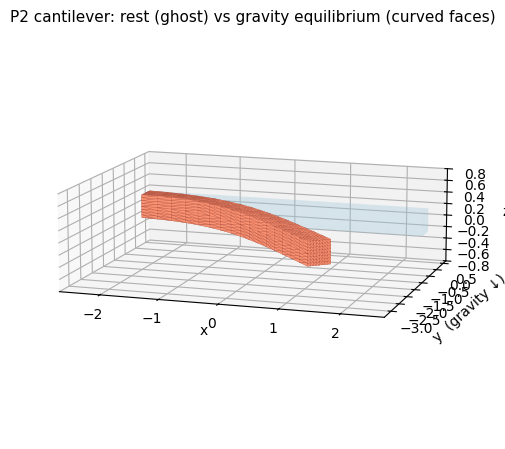

In [7]:
W4, tris4 = patch_basis(4)        # fine subdivision for a crisp still image

fig = plt.figure(figsize=(10, 4.6))
ax = fig.add_subplot(111, projection="3d")
ax.add_collection3d(Poly3DCollection(curved_surface(V2, W4, tris4),
                                     facecolor=utils.MESH_FACE, edgecolor="none", alpha=0.18))
ax.add_collection3d(Poly3DCollection(curved_surface(sol, W4, tris4),
                                     facecolor="#fc9272", edgecolor=(0.3, 0, 0, 0.25),
                                     lw=0.25, alpha=0.97))
setup_3d(ax, "P2 cantilever: rest (ghost) vs gravity equilibrium (curved faces)")
fig.tight_layout()
fig.savefig("media/20_p2_beam_static.png", dpi=120, bbox_inches="tight")
plt.show()

## 4 &middot; Watch it fall — dynamic backward-Euler

Static equilibrium is the end state; the dynamics are just as easy. Each step is
a backward-Euler solve that adds the inertial term
$\tfrac{1}{2h^2}\lVert x - \tilde x\rVert_M^2$ (with $\tilde x = x_n + h v_n$) to
the same potential — the consistent P2 mass matrix `M` is what makes this a P2
time step. `P2TetBeam.step` builds those inertia-augmented closures and
Newton-solves them. We release the beam from rest and let it swing down and
settle.

In [8]:
h, nsteps, stride = 0.02, 70, 3

U = V2.reshape(-1, 1).copy()
Vv = np.zeros_like(U)
frames = [V2.copy()]
for s in range(nsteps):
    U_next = beam.step(U, Vv, h=h)
    Vv = (U_next - U) / h
    U = U_next
    if (s + 1) % stride == 0:
        frames.append(U.reshape(n2, dim).copy())

print(f"{len(frames)} animation frames; settled tip y = {frames[-1][tip,1].mean():+.3f}")

24 animation frames; settled tip y = -4.019


In [9]:
# Animate the curved P2 surface as the beam swings down (coarser subdivision for speed).
W2, tris2 = patch_basis(2)

fig = plt.figure(figsize=(8.5, 4.4))
ax = fig.add_subplot(111, projection="3d")
ghost = Poly3DCollection(curved_surface(V2, W2, tris2),
                         facecolor=utils.MESH_FACE, edgecolor="none", alpha=0.12)
beam_poly = Poly3DCollection(curved_surface(frames[0], W2, tris2),
                             facecolor="#fc9272", edgecolor=(0.3, 0, 0, 0.25), lw=0.2, alpha=0.97)
ax.add_collection3d(ghost); ax.add_collection3d(beam_poly)
setup_3d(ax, "P2 beam released under gravity (backward Euler)")

def update(i):
    beam_poly.set_verts(curved_surface(frames[i], W2, tris2))
    return ()

anim = FuncAnimation(fig, update, frames=len(frames), interval=1000/24, blit=False)
fig.tight_layout()
utils.show_video(fig, anim, "media/20_p2_beam_fall.mp4", fps=24)

## 5 &middot; P1 vs P2 — same mesh, more accurate bending

Finally, solve the *identical* problem with ordinary **linear** tets on the same
`(X, T)` and compare. Bending is where low-order elements struggle: linear tets
**lock**, coming out far too stiff, so their tip barely moves. The P2 mesh — same
elements, same material — bends much more realistically, and it does so with
*genuinely curved* geometry that no amount of flat-triangle subdivision can
reproduce.

In [10]:
# --- P1 (linear) static equilibrium on the same mesh ---
mu0, lam0 = simkit.ympr_to_lame(1.2e4, 0.45)
J1   = simkit.deformation_jacobian(X, T)
vol1 = simkit.volume(X, T)
fg1  = simkit.gravity_force(X, T, a=GRAV, rho=RHO).reshape(-1, 1)
pin1 = np.where(X[:, 0] <= X[:, 0].min() + 1e-9)[0]
Q1, b1 = simkit.dirichlet_penalty(pin1, X[pin1], n1, gamma=1e8)
mu1  = np.full((vol1.shape[0], 1), mu0)
lam1 = np.full((vol1.shape[0], 1), lam0)

def E1(x):
    xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
    E_elastic = energies.macklin_mueller_neo_hookean_energy_x(xn, J1, mu1, lam1, vol1)
    E_pin     = 0.5 * (xc.T @ (Q1 @ xc))[0, 0] + (b1.T @ xc)[0, 0]
    E_gravity = -(fg1.T @ xc)[0, 0]
    return E_elastic + E_pin + E_gravity

def G1(x):
    xn, xc = x.reshape(-1, dim), x.reshape(-1, 1)
    g_elastic = energies.macklin_mueller_neo_hookean_gradient_x(xn, J1, mu1, lam1, vol1)
    g_pin     = Q1 @ xc + b1
    g_gravity = -fg1
    return g_elastic + g_pin + g_gravity

def H1(x):
    xn = x.reshape(-1, dim)
    H_elastic = energies.macklin_mueller_neo_hookean_hessian_x(xn, J1, mu1, lam1, vol1, psd=True)
    H_pin     = Q1
    return H_elastic + H_pin

sol1 = newton_solver(X.reshape(-1, 1).copy(), E1, G1, H1,
                     max_iter=300, tolerance=1e-9).reshape(n1, dim)

tip1 = np.where(X[:, 0] >= X[:, 0].max() - 1e-9)[0]
d1 = V2[tip,1].mean() - sol1[tip1,1].mean()
d2 = V2[tip,1].mean() - sol[tip,1].mean()
print(f"P1 tip drop: {d1:.3f}   ({n1*dim} dofs)")
print(f"P2 tip drop: {d2:.3f}   ({n2*dim} dofs)  ->  P2 deflects {100*(d2-d1)/d1:.0f}% more (P1 locks)")

P1 tip drop: 0.417   (135 dofs)
P2 tip drop: 2.786   (627 dofs)  ->  P2 deflects 568% more (P1 locks)


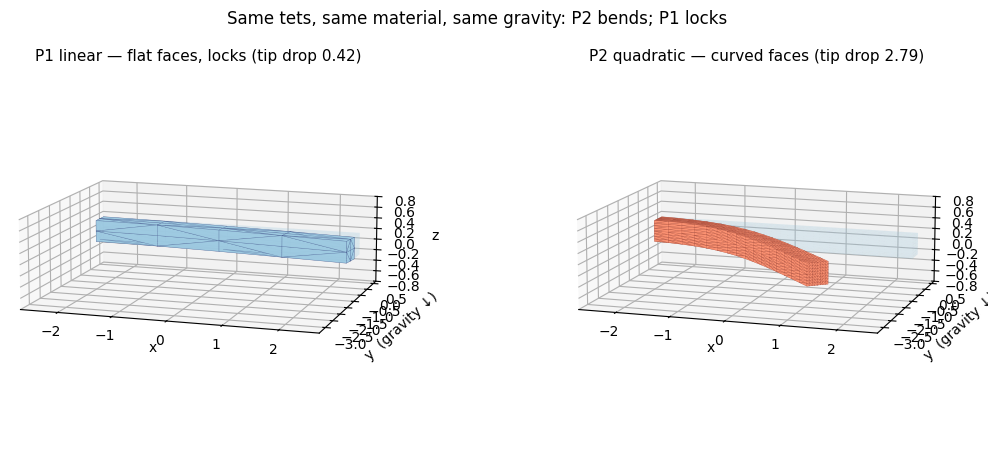

In [11]:
# P1 drawn with its native flat boundary triangles; P2 with its true curved faces.
def p1_boundary_polys(U1):
    count = {}
    for el in T:
        for f in _TET_FACES:
            key = tuple(sorted(int(el[c]) for c in f)); count[key] = count.get(key, 0) + 1
    polys = []
    for el in T:
        for f in _TET_FACES:
            key = tuple(sorted(int(el[c]) for c in f))
            if count[key] == 1:
                polys.append(U1[list(key)])
    return polys

fig = plt.figure(figsize=(12, 4.6))
axL = fig.add_subplot(121, projection="3d")
axL.add_collection3d(Poly3DCollection(p1_boundary_polys(X),
                     facecolor=utils.MESH_FACE, edgecolor="none", alpha=0.15))
axL.add_collection3d(Poly3DCollection(p1_boundary_polys(sol1),
                     facecolor="#9ecae1", edgecolor=(0, 0, 0.3, 0.3), lw=0.3, alpha=0.97))
setup_3d(axL, f"P1 linear — flat faces, locks (tip drop {d1:.2f})")

axR = fig.add_subplot(122, projection="3d")
axR.add_collection3d(Poly3DCollection(curved_surface(V2, W4, tris4),
                     facecolor=utils.MESH_FACE, edgecolor="none", alpha=0.15))
axR.add_collection3d(Poly3DCollection(curved_surface(sol, W4, tris4),
                     facecolor="#fc9272", edgecolor=(0.3, 0, 0, 0.25), lw=0.25, alpha=0.97))
setup_3d(axR, f"P2 quadratic — curved faces (tip drop {d2:.2f})")

fig.suptitle("Same tets, same material, same gravity: P2 bends; P1 locks", fontsize=12)
fig.tight_layout()
fig.savefig("media/20_p1_vs_p2_beam.png", dpi=120, bbox_inches="tight")
plt.show()

## Takeaways

- The entire P2 stack — `linear_to_quadratic_elements`, `gauss_legendre_quadrature`,
  `deformation_jacobian_p2`, `p2_massmatrix`, `p2_gravity_force` — works in **3D
  on tets** exactly as it does on 2D triangles; only the node count per element
  (10 vs 6) changes.
- P2 evaluates **one deformation gradient per cubature point**, so the energy
  integral becomes a quadrature sum. The elastic energy, the Newton solver and
  the Dirichlet pin are the **unchanged P1 code**.
- On a bending-dominated cantilever, linear tets **lock** (too stiff) while the
  quadratic mesh deflects realistically and renders with **true curved
  geometry** — the defining advantage of P2.